# 05 — Scaling the Surprise Strategy: CPI Only vs CPI + Other Macro Surprises (ES)

## Purpose

Notebook 04 showed that trading ES in the direction of the **CPI surprise** earns a net Sharpe of about 1.0, but only about **7–11 trades a year**. The peer DTW strategy (Jack Duncan) trades about **185 times a year on ES**.

This notebook asks:

> **If we trade the surprises of many US macro releases, not only CPI, how many trades do we get, and do we keep a positive, credible edge after costs?**

The final section compares **CPI only** against **CPI + other surprises** on trades per year, P&L, return, Sharpe, drawdown, hit rate and costs.

**Scope:** ES only, so the comparison with the peer ES strategy is like for like.

**Credits:** the release-family rule, the impact screen and the volatility-proportional sizing come from **Jack Duncan** (`blackrock-intraday/jack/strategy_proposal.md`). The 5σ winsorisation of surprises comes from **Aaryen Mehta**. The causal surprise standardisation, the executable entry and the walk-forward engine come from this project (Notebooks 01–04).

## Notebook Workflow

| Step | What happens |
|---|---|
| 1 | Setup and pre-registered parameters |
| 2 | Read every US release in the Bloomberg workbook and group lines into release **families** |
| 3 | Causal, winsorised surprise for every line |
| 4 | ES price measures at every release: jump, tradeable 30-min drift, second 30 min, 4-hour volatility |
| 5 | Validation: the CPI trades must reproduce Notebook 04 |
| 6 | **Impact screen**: each year, admit the 10 families the market reacts to most (history only) |
| 7 | Direction: line signs from the jump regression (history only), then family signals |
| 8 | Strategies: CPI only vs all admitted families; flat, surprise-model and volatility sizing; one vs two windows |
| 9 | Performance, per-family results, robustness (periods, costs, random-sign null) |
| 10 | **Final comparison: CPI only vs CPI + other surprises** |

## Methodology: fixed before looking at results

1. **Entry and exit as in Notebook 04.** Entry at the close of the first post-release bar (about 1 minute after the release, "T+1"), exit 30 minutes after the release. The instant jump is **never** traded.
2. **Release families.** Bloomberg lines that print at the same instant (CPI MoM, Core CPI MoM, CPI YoY and so on) are one release. Lines sharing ≥80% of their timestamps form one family.
3. **Surprise.** $z = (\text{actual} - \text{consensus}) / \text{sd of the line's previous surprises}$, with at least 24 prior releases, capped at ±5σ.
4. **Universe (impact screen).** At the start of each year, using **only earlier data**:
   $$\text{impact}_f = \frac{\text{mean}\,|\text{30-min move}| \text{ on } f\text{'s releases}}{\text{mean}\,|\text{30-min move}| \text{ at the same clock time when another family releases}}$$
   The top **K = 10** families are admitted for that year. No P&L is used.
5. **Direction.** Each line's sign comes from regressing the **instant jump** on its surprise over earlier years, which avoids any drift P&L. The family signal is $x = \text{mean}(\text{sign} \times z)$, so $x>0$ always means *good news for ES*.
6. **Three sizing rules:**
   - **Naive:** one unit in the direction of $x$.
   - **Surprise model:** $\hat r = \hat b_f\,x$, re-fitted on the family's earlier releases; trade only if $|\hat r|$ exceeds the cost.
   - **Signal × volatility (Jack):** position ∝ clip($x$, ±3) × 4-hour volatility / its historical median, normalised to about 1 unit on average.
7. **Costs** are the same as Notebook 04: 2 ticks round trip plus $4.50 commission per contract.
8. **Evaluation** covers 2019–2026, the same window as Notebook 04. 2016–2018 is history only.

## 1. Setup and Project Paths

In [1]:
from pathlib import Path
import sys, importlib, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BBG_FILE = RAW_DIR / "Bloomberg Economic Releases.xlsx"
ES_RAW_FILE = RAW_DIR / "ES_1m_2010_2026_full.parquet"
NB04_LOG = RESULTS_DIR / "nb04_trade_log.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
import src.walk_forward as wf
import src.surprise_universe as su
for m in (sc, wf, su):
    importlib.reload(m)

for f in [BBG_FILE, ES_RAW_FILE, NB04_LOG]:
    print(f"{f.name:<40s} exists: {f.exists()}")

Bloomberg Economic Releases.xlsx         exists: True
ES_1m_2010_2026_full.parquet             exists: True
nb04_trade_log.csv                       exists: True


### 1.1 Pre-registered parameters

In [2]:
HIST_START = "2016-01-01"      # history used for screens, signs and model fits
EVAL_START, EVAL_END = "2019-01-01", "2026-06-30"
EVAL_YEARS = list(range(2019, 2027))
K_FAMILIES = 10                # families admitted each year (Jack's specification)
MIN_TRAIN = 24                 # earlier releases needed before a family is modelled
TICKS_RT, COMMISSION_RT = 2.0, 4.5
THRESHOLD = 1.0                # surprise model trades if |E[r]| > 1 x cost
N_NULL, N_BOOT = 1000, 5000
CPI = "CPI"
PRIMARY_TARGET = "w1"          # T+1 -> T+30, the Notebook 04 window
N_YEARS = (pd.Timestamp(EVAL_END) - pd.Timestamp(EVAL_START)).days / 365.25
print(f"Evaluation {EVAL_START} to {EVAL_END} ({N_YEARS:.2f} years), K = {K_FAMILIES}")

Evaluation 2019-01-01 to 2026-06-30 (7.49 years), K = 10


## 2. US Releases and Release Families

In [3]:
t0 = time.time()
rows = su.load_bloomberg(BBG_FILE)
print(f"Release rows: {len(rows):,}  |  lines (tickers): {rows['ticker'].nunique()}  |  read in {time.time()-t0:.0f}s")
print("Range:", rows["ts_et"].min(), "to", rows["ts_et"].max())

fam = su.build_families(rows)
print(f"\nLines with >= 30 releases since 2013: {len(fam)}  ->  families: {fam['family'].nunique()}")
fam_summary = (fam.groupby("family")
                  .agg(lines=("ticker", "size"), clock=("clock_et", lambda s: s.mode().iat[0]),
                       releases=("n_releases", "max"),
                       example_lines=("event_name", lambda s: "; ".join(list(s)[:4])))
                  .sort_values("lines", ascending=False))
display(fam_summary.head(25))

Release rows: 27,137  |  lines (tickers): 179  |  read in 1s
Range: 2010-01-04 10:00:00-05:00 to 2026-07-17 10:00:00-04:00

Lines with >= 30 releases since 2013: 143  ->  families: 75


,lines,clock,releases,example_lines
family,,,,
Employment Report (NFP),10,08:30,162,Average Hourly Earnings MoM; Average Hourly Ea...
CPI,8,08:30,162,CPI MoM; Core CPI YoY; CPI YoY; Core CPI Index SA
Personal Income / PCE,7,08:30,160,Real Personal Spending; Core PCE Price Index M...
PPI,6,08:30,149,PPI Final Demand MoM; PPI Ex Food and Energy M...
U. of Michigan Sentiment,5,10:00,325,U. of Mich. Current Conditions; U. of Mich. Ex...
Durable Goods,4,08:30,290,Cap Goods Orders Nondef Ex Air; Cap Goods Ship...
Housing Starts,4,08:30,176,Building Permits MoM; Housing Starts MoM; Buil...
GDP,4,08:30,160,GDP Annualized QoQ; GDP Price Index; Core PCE ...
Retail Sales,4,08:30,163,Retail Sales Advance MoM; Retail Sales Ex Auto...


**Check.** CPI MoM, Core CPI MoM, CPI YoY and the CPI index lines should form one **CPI** family. Payrolls, the unemployment rate and hourly earnings should form one **Employment Report** family. Each is one print, so each is one trade.

## 3. Causal Surprises

In [4]:
surp = su.standardise_surprises(rows)
surp = surp[surp["ticker"].isin(fam["ticker"])]
print(f"Surprise rows with a consensus: {len(surp):,}  |  with a causal z-score: {surp['z'].notna().sum():,}")
print(f"Share capped at +/-5 sigma: {(surp['z'].abs() >= 5).mean():.2%}")
display(surp.merge(fam[["ticker", "family"]], on="ticker")
            .query("family == @CPI")[["ts_et", "event_name", "survey_median", "actual", "raw", "z"]].tail(8))

Surprise rows with a consensus: 20,365  |  with a causal z-score: 17,328
Share capped at +/-5 sigma: 0.47%


,ts_et,event_name,survey_median,actual,raw,z
4700,2026-01-13 08:30:00-05:00,CPI Index NSA,324.168,324.054,-0.115,-0.422
4701,2026-02-13 08:30:00-05:00,CPI Index NSA,325.514,325.252,-0.262,-0.968
4702,2026-03-11 08:30:00-04:00,CPI Index NSA,326.762,326.785,0.024,0.087
4703,2026-04-10 08:30:00-04:00,CPI Index NSA,330.555,330.213,-0.342,-1.267
4704,2026-05-12 08:30:00-04:00,CPI Index NSA,332.690,333.020,0.330,1.220
4705,2026-06-10 08:30:00-04:00,CPI Index NSA,335.143,335.123,-0.020,-0.074
4706,2026-07-14 08:30:00-04:00,CPI Index NSA,334.698,333.952,-0.746,-2.762
17061,2019-01-11 08:30:00-05:00,Real Avg Weekly Earnings YoY,1.200,1.184,-0.016,NaN


## 4. ES Price Measures at Every Release

In [5]:
es = sc.load_es_minute(ES_RAW_FILE)
es_adj, _ = sc.build_adjusted_log_price(es)
ts_all = rows.loc[rows["ts_utc"] >= pd.Timestamp(HIST_START, tz="UTC"), "ts_utc"].unique()
px = su.price_measures(es_adj, ts_all)
px["cost_bps"] = su.cost_bps(px["pre_close"], TICKS_RT, COMMISSION_RT)
print(f"Release timestamps since {HIST_START}: {len(px):,}  |  with a 30-min trade return: {px['w1'].notna().sum():,}")
display(px.describe().T[["count", "mean", "std", "min", "50%", "max"]])

Release timestamps since 2016-01-01: 6,097  |  with a 30-min trade return: 5,920


,count,mean,std,min,50%,max
jump,"5,998.000",0.254,12.071,-241.564,0.000,219.149
w1,"5,920.000",0.107,22.562,-240.702,0.348,395.175
w2,"5,915.000",-0.048,20.816,-274.760,0.000,254.984
react30,"5,920.000",0.346,25.995,-297.103,0.767,404.828
vol_4h,"5,998.000",2.332,1.745,0.000,1.847,28.199
pre_close,"5,998.000","3,911.339","1,468.026","1,816.250","3,764.375","7,628.500"
cost_bps,"5,998.000",1.725,0.613,0.773,1.567,3.248


## 5. Validation: Do the CPI Trades Reproduce Notebook 04?

In [6]:
nb04 = pd.read_csv(NB04_LOG)
nb04["timestamp_utc"] = pd.to_datetime(nb04["timestamp_utc"], utc=True)
nb04_cpi = nb04[(nb04["strategy"] == "Naive sign") & (nb04["event_type"] == "CPI") & nb04["eligible"]]
chk = nb04_cpi.merge(px, left_on="timestamp_utc", right_on="ts_utc", how="inner")
gap = (chk["ret_bps"] - chk["w1"]).abs()
print(f"NB04 CPI trades: {len(nb04_cpi)}  |  matched release timestamps: {len(chk)}")
print(f"Max |NB04 trade return - NB05 w1| = {gap.max():.2e} bps")
if len(chk) < len(nb04_cpi):
    print(f"WARNING: {len(nb04_cpi) - len(chk)} NB04 CPI timestamps are not in the Bloomberg calendar")
assert gap.max() < 1e-6, "Trade returns differ from Notebook 04: check the ES file and bar convention"
print("PASSED: the 30-minute trade return is identical to Notebook 04 on every matched CPI release")

NB04 CPI trades: 86  |  matched release timestamps: 86
Max |NB04 trade return - NB05 w1| = 3.55e-15 bps
PASSED: the 30-minute trade return is identical to Notebook 04 on every matched CPI release


## 6. Impact Screen: Which Families Does the Market React To?

Computed once per year from history only. The admitted list can change from year to year.

In [7]:
screens = {}
for y in EVAL_YEARS:
    screens[y] = su.impact_screen(rows, fam, px, HIST_START, f"{y}-01-01")
admit = pd.DataFrame({y: screens[y].set_index("family")["rank"] for y in EVAL_YEARS})
admitted_any = admit[(admit <= K_FAMILIES).any(axis=1)]
print(f"Families ranked each year: {[len(screens[y]) for y in EVAL_YEARS]}")
print(f"\nRank of every family that is admitted (top {K_FAMILIES}) in at least one year:")
display(admitted_any.sort_values(EVAL_YEARS[-1]).astype("Int64"))
print(f"\nScreen used for {EVAL_YEARS[0]} (history {HIST_START} to {EVAL_YEARS[0]-1}):")
display(screens[EVAL_YEARS[0]].head(15))
admit.to_csv(RESULTS_DIR / "nb05_impact_rank_by_year.csv")

Families ranked each year: [36, 39, 39, 39, 40, 42, 43, 45]

Rank of every family that is admitted (top 10) in at least one year:


,2019,2020,2021,2022,2023,2024,2025,2026
family,,,,,,,,
CPI,2,4,5,3,1,1,1,1
Employment Report (NFP),1,1,1,1,4,3,3,2
Fed Interest on Reserve Balances Rate,<NA>,<NA>,<NA>,<NA>,2,2,2,3
FOMC Rate Decision,<NA>,2,2,2,3,4,4,4
ISM Manufacturing,8,6,12,13,5,8,6,5
U. of Michigan Sentiment,22,25,22,16,7,6,7,6
ISM Services,5,7,7,7,6,5,5,7
JOLTS,13,15,8,9,11,7,8,8
Dallas Fed Manf. Activity,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,9



Screen used for 2019 (history 2016-01-01 to 2018):


,family,clock,n,n_control,impact,t,survey_share,rank
0,Employment Report (NFP),08:30,36,407,2.230,3.347,1.000,1
1,CPI,08:30,35,408,1.890,2.039,1.000,2
2,Retail Sales,08:30,35,408,1.786,1.729,1.000,3
3,Trade Balance,08:30,36,407,1.553,1.402,1.000,4
4,ISM Services,10:00,36,416,1.319,1.052,1.000,5
5,Case-Shiller 20-City,09:00,36,31,1.284,1.213,1.000,6
6,Pending Home Sales MoM,10:00,36,416,1.185,0.707,1.000,7
7,ISM Manufacturing,10:00,36,416,1.169,0.900,1.000,8
8,Empire Manufacturing,08:30,36,407,1.149,0.667,1.000,9
9,Factory Orders,10:00,36,416,1.101,0.471,1.000,10


**How to read it.** An impact of 1.3 means the ES reaction to this family is 30% larger than at the same clock time when a different release is out. Only the top 10 each year are traded. CPI should rank near the top in every year.

## 7. Direction: Line Signs and Family Signals

In [8]:
signs, hist = {}, {}
admitted = {y: set(screens[y].head(K_FAMILIES)["family"]) for y in EVAL_YEARS}
for y in EVAL_YEARS:
    signs[y] = su.line_signs(surp, px, HIST_START, f"{y}-01-01")
    fams_y = admitted[y] | {CPI}
    # training panel for the surprise model: releases before the end of year y
    hist[y] = su.history_panel(surp, fam, px, fams_y, signs[y], HIST_START, f"{y+1}-01-01")

screen_plus_cpi = {y: pd.DataFrame({"family": sorted(admitted[y] | {CPI})}) for y in EVAL_YEARS}
panel = su.family_signal_panel(surp, fam, px, screen_plus_cpi, signs, EVAL_YEARS)
panel["year"] = panel["ts_utc"].dt.tz_convert("America/New_York").dt.year
panel["admitted"] = [f in admitted[y] for f, y in zip(panel["family"], panel["year"])]
panel = panel[(panel["ts_utc"] >= pd.Timestamp(EVAL_START, tz="UTC")) &
              (panel["ts_utc"] <= pd.Timestamp(EVAL_END, tz="UTC"))]
print(f"Family-release rows in the evaluation period: {len(panel):,}  (admitted: {panel['admitted'].sum():,})")

cpi_signs = signs[EVAL_YEARS[0]][signs[EVAL_YEARS[0]].index.isin(fam.loc[fam['family'] == CPI, 'ticker'])]
print("\nCPI line signs (history to 2018): -1 means a hot print has pushed ES down")
display(cpi_signs.to_frame().join(fam.set_index("ticker")["event_name"]))

# sanity: the signed family signal should be positively related to the instant jump
sanity = panel.groupby("family").apply(lambda g: g["x"].corr(g["jump"])).rename("corr(x, jump)")
display(sanity.sort_values(ascending=False).to_frame())

Family-release rows in the evaluation period: 860  (admitted: 860)

CPI line signs (history to 2018): -1 means a hot print has pushed ES down


,sign,event_name
CPI CHNG Index,-1.000,CPI MoM
CPI XYOY Index,-1.000,Core CPI YoY
CPI YOY Index,-1.000,CPI YoY
CPUPAXFE Index,-1.000,Core CPI Index SA
CPUPXCHG Index,-1.000,Core CPI MoM
CPURNSA Index,-1.000,CPI Index NSA


,"corr(x, jump)"
family,
U. of Michigan Sentiment,0.584
CPI,0.546
Pending Home Sales MoM,0.516
PPI,0.408
ISM Manufacturing,0.371
Retail Sales,0.237
GDP,0.206
Business Inventories,0.199
Employment Report (NFP),0.183


**Check.** Because each line is signed so that $x>0$ means good news, the correlation between $x$ and the instant jump should be **positive** for most families, and strongly so for CPI. This is measured in the evaluation period, which the signs never saw.

## 8. Strategies

| Strategy | Families | Sizing | Window |
|---|---|---|---|
| **CPI · naive** | CPI | sign of $x$ | 1 |
| **CPI · surprise model** | CPI | $\hat b x$ vs cost (Notebook 04 style) | 1 |
| CPI · signal × vol | CPI | Jack's sizing | 1 |
| **All · naive** | 10 admitted families (CPI included when admitted) | sign of $x$ | 1 |
| **All · surprise model** | 10 admitted | $\hat b_f x$ vs cost | 1 |
| **All · signal × vol** | 10 admitted | Jack's sizing | 1 |
| **Combined** | CPI + other admitted | CPI surprise model + others signal × vol | 1 |
| All · naive · 2nd window | 10 admitted | sign of $x$ | 2 only (T+30 → T+60) |
| All · signal × vol · 2 windows | 10 admitted | Jack's sizing | 1 and 2 |

Window 1 is T+1 → T+30 (Notebook 04). Window 2 is T+30 → T+60, a pre-registered test of whether a second trade per release (as in the peer strategy) earns anything.

In [9]:
def positions(sub, model, target=PRIMARY_TARGET):
    return su.build_positions(sub, hist, model, target, MIN_TRAIN, THRESHOLD)

cpi_p = panel[panel["family"] == CPI]
all_p = panel[panel["admitted"]]
oth_p = all_p[all_p["family"] != CPI]

P = {
    "CPI · naive": positions(cpi_p, "naive"),
    "CPI · surprise model": positions(cpi_p, "surprise"),
    "CPI · signal × vol": positions(cpi_p, "signal_vol"),
    "All · naive": positions(all_p, "naive"),
    "All · surprise model": positions(all_p, "surprise"),
    "All · signal × vol": positions(all_p, "signal_vol"),
}
P["Combined (CPI model + others × vol)"] = pd.concat([positions(cpi_p, "surprise"), positions(oth_p, "signal_vol")])

T = {name: su.to_trades(p, PRIMARY_TARGET, name) for name, p in P.items()}

# second window
p_nw2 = positions(all_p, "naive", "w2")
T["All · naive · 2nd window"] = su.to_trades(p_nw2, "w2", "All · naive · 2nd window")
t_w1 = su.to_trades(P["All · signal × vol"], "w1", "x")
t_w2 = su.to_trades(P["All · signal × vol"], "w2", "x")
t_w2["timestamp_utc"] = t_w2["timestamp_utc"] + pd.Timedelta(minutes=30)
T["All · signal × vol · 2 windows"] = pd.concat([t_w1, t_w2]).sort_values("timestamp_utc").assign(
    strategy="All · signal × vol · 2 windows").reset_index(drop=True)

STRATS = list(T)
pd.concat(T.values()).to_csv(RESULTS_DIR / "nb05_trade_log.csv", index=False)
display(pd.DataFrame({k: {"release timestamps": len(v), "trades": int((v["position"] != 0).sum())} for k, v in T.items()}).T)

,release timestamps,trades
CPI · naive,89,89
CPI · surprise model,89,67
CPI · signal × vol,89,88
All · naive,809,744
All · surprise model,809,321
All · signal × vol,809,754
Combined (CPI model + others × vol),809,733
All · naive · 2nd window,809,744
All · signal × vol · 2 windows,1618,1508


## 9. Performance

### 9.1 Main metrics (evaluation 2019–2026, net of costs)

In [10]:
KEY = ["trades", "hit_rate", "avg_gross_bps", "avg_cost_bps", "avg_net_bps", "total_net_pct",
       "ann_return_pct", "ann_vol_pct", "sharpe_gross", "sharpe_net", "max_dd_pct", "t_stat_trade", "profit_factor"]
perf = wf.perf_table(T, EVAL_START, EVAL_END)
perf["trades_per_year"] = perf["trades"] / N_YEARS
perf["days_per_year"] = [
    pd.to_datetime(T[s].loc[T[s]["position"] != 0, "timestamp_utc"]).dt.tz_convert("America/New_York").dt.date.nunique() / N_YEARS
    for s in perf.index]
perf.to_csv(RESULTS_DIR / "nb05_performance.csv")
display(perf[["trades_per_year", "days_per_year"] + KEY].round(3))

,trades_per_year,days_per_year,trades,hit_rate,avg_gross_bps,avg_cost_bps,avg_net_bps,total_net_pct,ann_return_pct,ann_vol_pct,sharpe_gross,sharpe_net,max_dd_pct,t_stat_trade,profit_factor
strategy,,,,,,,,,,,,,,,
CPI · naive,11.744,11.877,88,0.545,6.321,1.403,4.918,4.328,0.577,1.132,0.654,0.510,-2.196,1.397,1.501
CPI · surprise model,8.941,8.941,67,0.582,9.604,1.377,8.228,5.513,0.735,0.972,0.878,0.756,-2.035,2.084,1.969
CPI · signal × vol,11.744,11.744,88,0.545,14.659,1.495,13.164,11.585,1.545,2.013,0.844,0.767,-2.641,2.102,2.668
All · naive,98.352,90.745,737,0.507,3.148,1.412,1.736,12.793,1.706,2.638,1.170,0.647,-4.836,1.823,1.216
All · surprise model,42.837,41.503,321,0.470,1.846,1.425,0.421,1.351,0.180,1.596,0.492,0.113,-3.243,0.297,1.047
All · signal × vol,100.621,91.546,754,0.509,3.872,1.174,2.698,20.340,2.712,4.830,0.804,0.561,-13.831,1.671,1.356
Combined (CPI model + others × vol),97.818,88.744,733,0.512,3.131,1.165,1.966,14.414,1.922,4.759,0.645,0.404,-14.288,1.294,1.258
All · naive · 2nd window,97.952,90.745,734,0.448,-0.153,1.412,-1.566,-11.493,-1.532,1.932,-0.078,-0.793,-13.503,-2.181,0.796
All · signal × vol · 2 windows,200.841,91.546,1505,0.478,1.724,1.176,0.547,8.236,1.098,6.968,0.504,0.158,-23.833,0.505,1.071


**How to read it.** Compare **CPI · surprise model** (the Notebook 04 strategy) with the **All** rows. The All rows trade far more often. The question is whether `avg_net_bps` and `sharpe_net` stay positive once the weaker releases are added.

### 9.2 Which families earn money?

,naive_trades,naive_hit_rate,naive_avg_net_bps,naive_t_stat,naive_total_net_pct,vol_trades,vol_hit_rate,vol_avg_net_bps,vol_t_stat,vol_total_net_pct
family,,,,,,,,,,
CPI,89,0.539,4.918,1.405,4.328,88,0.545,12.725,2.040,11.198
JOLTS,53,0.509,5.653,1.556,2.996,53,0.509,9.659,1.131,5.119
Retail Sales,83,0.530,2.764,1.116,2.294,83,0.530,-1.654,-0.318,-1.373
U. of Michigan Sentiment,84,0.464,1.818,0.669,1.418,78,0.500,6.274,1.315,4.894
Advance Goods Trade Balance,24,0.625,5.520,1.134,1.325,24,0.625,7.937,0.979,1.905
ISM Manufacturing,76,0.539,1.174,0.390,0.893,76,0.539,0.870,0.333,0.662
Factory Orders,22,0.545,3.960,0.530,0.871,22,0.545,-11.835,-0.652,-2.604
Trade Balance,45,0.467,1.569,0.539,0.706,45,0.467,-0.076,-0.054,-0.034
Dallas Fed Manf. Activity,6,0.833,11.445,1.928,0.687,6,0.833,2.154,1.077,0.129


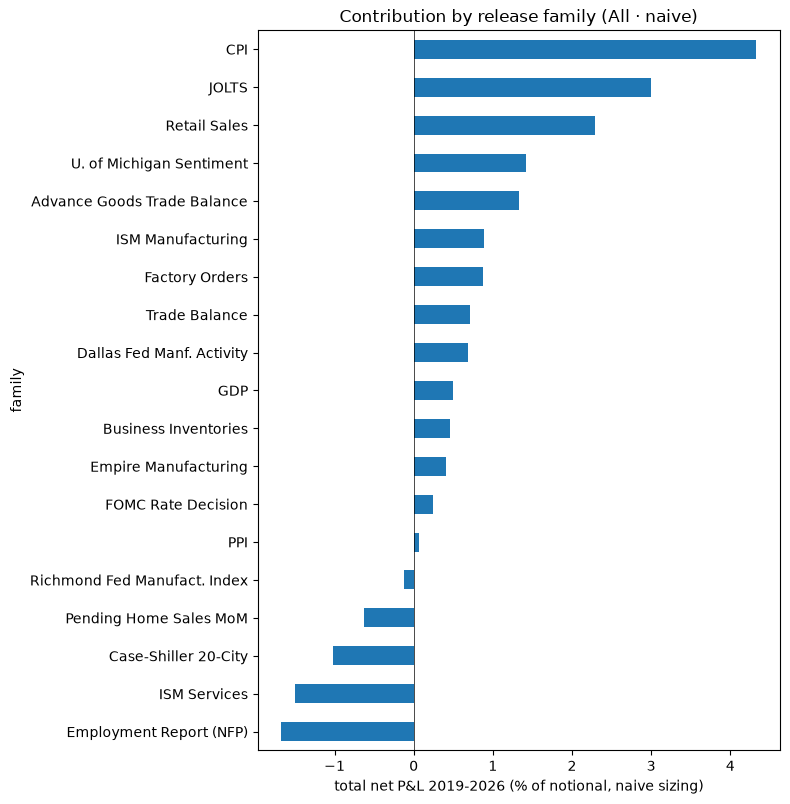

In [11]:
fam_naive = su.per_family_stats(P["All · naive"], PRIMARY_TARGET).add_prefix("naive_")
fam_vol = su.per_family_stats(P["All · signal × vol"], PRIMARY_TARGET).add_prefix("vol_")
fam_tab = fam_naive.join(fam_vol, how="outer").sort_values("naive_total_net_pct", ascending=False)
fam_tab.to_csv(RESULTS_DIR / "nb05_per_family.csv")
display(fam_tab.round(3))

ax = fam_tab["naive_total_net_pct"].sort_values().plot.barh(figsize=(8, 0.35 * len(fam_tab) + 1.5), color="C0")
ax.axvline(0, c="k", lw=0.5); ax.set_xlabel("total net P&L 2019-2026 (% of notional, naive sizing)")
ax.set_title("Contribution by release family (All · naive)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "nb05_family_contribution.png", dpi=150); plt.show()

### 9.3 Cumulative P&L

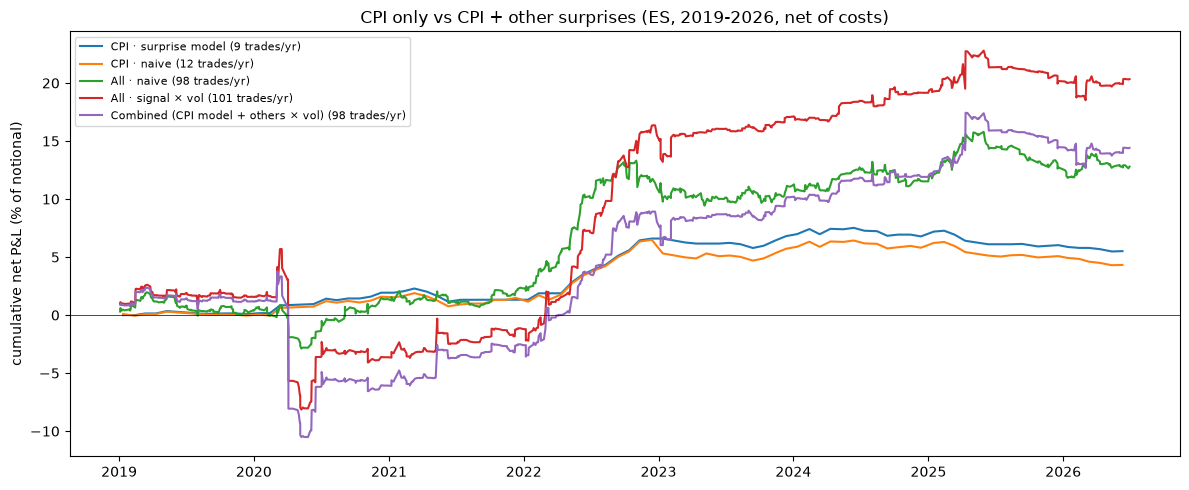

In [12]:
SHOW = ["CPI · surprise model", "CPI · naive", "All · naive", "All · signal × vol", "Combined (CPI model + others × vol)"]
fig, ax = plt.subplots(figsize=(12, 5))
for i, s in enumerate(SHOW):
    cum, _ = wf.drawdown_series(T[s], EVAL_START, EVAL_END)
    ax.plot(cum.index, cum.values, label=f"{s} ({perf.loc[s, 'trades_per_year']:.0f} trades/yr)", lw=1.5)
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("cumulative net P&L (% of notional)")
ax.set_title("CPI only vs CPI + other surprises (ES, 2019-2026, net of costs)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "nb05_cumulative_pnl.png", dpi=150); plt.show()

### 9.4 Robustness: sub-periods, 2022, and the random-sign null

In [13]:
def sharpe_months(tr, start, end, drop_year=None):
    m = wf.monthly_returns(tr, start, end)
    if drop_year:
        m = m[m.index.year != drop_year]
    sd = m.std(ddof=1)
    return m.mean() / sd * np.sqrt(12) if sd > 0 else np.nan

rob = []
for s in STRATS:
    obs, p_null = su.random_sign_pvalue(T[s], wf.monthly_returns, EVAL_START, EVAL_END, n=N_NULL)
    (lo, _, hi), _ = wf.bootstrap_sharpe(T[s], EVAL_START, EVAL_END, N_BOOT)
    rob.append(dict(strategy=s, sharpe=obs, ci_5=lo, ci_95=hi,
                    sharpe_2019_21=sharpe_months(T[s], "2019-01-01", "2021-12-31"),
                    sharpe_2022_26=sharpe_months(T[s], "2022-01-01", EVAL_END),
                    sharpe_ex_2022=sharpe_months(T[s], EVAL_START, EVAL_END, drop_year=2022),
                    p_random_sign=p_null))
rob = pd.DataFrame(rob).set_index("strategy")
rob.to_csv(RESULTS_DIR / "nb05_robustness.csv")
display(rob.round(3))

,sharpe,ci_5,ci_95,sharpe_2019_21,sharpe_2022_26,sharpe_ex_2022,p_random_sign
strategy,,,,,,,
CPI · naive,0.510,-0.188,1.241,0.665,0.473,-0.112,0.030
CPI · surprise model,0.756,0.038,1.486,0.630,0.831,0.049,0.006
CPI · signal × vol,0.767,0.046,1.484,0.528,0.909,0.052,0.008
All · naive,0.647,-0.080,1.347,0.321,0.833,0.275,0.000
All · surprise model,0.113,-0.606,0.732,0.075,0.138,-0.161,0.095
All · signal × vol,0.561,-0.066,1.481,-0.063,1.415,0.120,0.014
Combined (CPI model + others × vol),0.404,-0.213,1.297,-0.135,1.164,0.122,0.029
All · naive · 2nd window,-0.793,-1.430,-0.111,-1.628,-0.272,-1.029,0.585
All · signal × vol · 2 windows,0.158,-0.524,1.063,-0.723,1.126,-0.309,0.069


**How to read it.**
- **`p_random_sign`** is the share of random-direction books, with the same trades, sizes and costs, whose Sharpe beats the strategy. Below 0.05 means the *direction* genuinely adds value.
- **`sharpe_ex_2022`** shows how much depends on the 2022 inflation shock.

### 9.5 Transaction costs

In [14]:
cost_rows = []
for ticks in [0, 1, 2, 4]:
    pt = panel.copy()
    pt["cost_bps"] = su.cost_bps(pt["pre_close"], ticks, COMMISSION_RT)
    for s, (fams, model) in {"CPI · surprise model": ("cpi", "surprise"), "All · naive": ("all", "naive"),
                             "All · signal × vol": ("all", "signal_vol")}.items():
        sub = pt[pt["family"] == CPI] if fams == "cpi" else pt[pt["admitted"]]
        tr = su.to_trades(su.build_positions(sub, hist, model, PRIMARY_TARGET, MIN_TRAIN, THRESHOLD), PRIMARY_TARGET, s)
        pf = wf.performance(tr, EVAL_START, EVAL_END, s)
        cost_rows.append(dict(ticks_rt=ticks, strategy=s, sharpe_net=pf["sharpe_net"], avg_net_bps=pf["avg_net_bps"], trades=pf["trades"]))
cost_tab = pd.DataFrame(cost_rows)
cost_tab.to_csv(RESULTS_DIR / "nb05_cost_sensitivity.csv", index=False)
display(cost_tab.pivot(index="ticks_rt", columns="strategy", values="sharpe_net").round(2))

strategy,All · naive,All · signal × vol,CPI · surprise model
ticks_rt,,,
0,1.090,0.770,0.660
1,0.870,0.660,0.600
2,0.650,0.560,0.760
4,0.200,0.350,0.610


### 9.6 Peer-format metrics (daily, one contract)

In [15]:
daily_close = sc.build_daily_close(es_adj)
days = daily_close.index[(daily_close.index >= pd.Timestamp(EVAL_START)) & (daily_close.index <= pd.Timestamp(EVAL_END))]
bh = wf.buy_hold_daily(daily_close, days)
peer = {s: wf.peer_metrics(wf.daily_returns(T[s], days), bh, trades_per_year=perf.loc[s, "trades_per_year"],
                           minutes_in_market=perf.loc[s, "trades"] * 30 / (len(days) * 23 * 60) * 100) for s in STRATS}
peer = pd.DataFrame(peer).T
peer.to_csv(RESULTS_DIR / "nb05_peer_metrics.csv")
display(peer.round(3))

,total_pct,vol_pct,sharpe,max_dd_pct,beta,corr,trades_per_year,time_in_market_pct
CPI · naive,4.328,1.153,0.514,-2.196,-0.001,-0.018,11.744,0.104
CPI · surprise model,5.513,1.003,0.754,-2.035,-0.001,-0.022,8.941,0.079
CPI · signal × vol,11.585,2.078,0.764,-2.641,-0.003,-0.027,11.744,0.104
All · naive,13.030,2.585,0.691,-4.665,-0.001,-0.007,98.352,0.872
All · surprise model,1.198,1.705,0.096,-3.261,0.002,0.024,42.837,0.380
All · signal × vol,20.312,4.701,0.592,-13.831,-0.002,-0.008,100.621,0.892
Combined (CPI model + others × vol),14.389,4.334,0.455,-14.288,-0.000,-0.002,97.818,0.867
All · naive · 2nd window,-11.270,1.938,-0.797,-13.367,-0.003,-0.033,97.952,0.868
All · signal × vol · 2 windows,8.340,6.115,0.187,-23.728,-0.002,-0.006,200.841,1.780


## 10. Final Comparison: CPI Only vs CPI + Other Surprises

In [16]:
FINAL = ["CPI · naive", "CPI · surprise model", "CPI · signal × vol",
         "All · naive", "All · surprise model", "All · signal × vol",
         "Combined (CPI model + others × vol)", "All · signal × vol · 2 windows"]
final = pd.DataFrame({
    "trades / yr": perf.loc[FINAL, "trades_per_year"],
    "days / yr": perf.loc[FINAL, "days_per_year"],
    "hit rate": perf.loc[FINAL, "hit_rate"],
    "net bps / trade": perf.loc[FINAL, "avg_net_bps"],
    "total net P&L %": perf.loc[FINAL, "total_net_pct"],
    "ann. return %": perf.loc[FINAL, "ann_return_pct"],
    "ann. vol %": perf.loc[FINAL, "ann_vol_pct"],
    "Sharpe (net)": perf.loc[FINAL, "sharpe_net"],
    "Sharpe ex-2022": rob.loc[FINAL, "sharpe_ex_2022"],
    "max DD %": perf.loc[FINAL, "max_dd_pct"],
    "beta": peer.loc[FINAL, "beta"],
    "P(random sign ≥)": rob.loc[FINAL, "p_random_sign"],
})
jack = pd.DataFrame({"trades / yr": 185, "days / yr": np.nan, "hit rate": np.nan, "net bps / trade": 1.18,
                     "total net P&L %": 18.597, "ann. return %": np.nan, "ann. vol %": 3.020, "Sharpe (net)": 0.613,
                     "Sharpe ex-2022": np.nan, "max DD %": -4.928, "beta": -0.005, "P(random sign ≥)": np.nan},
                    index=["Peer: Jack DTW (slide, 2018-2026)"])
final = pd.concat([final, jack])
final.to_csv(RESULTS_DIR / "nb05_final_comparison.csv")
display(final.round(3))

,trades / yr,days / yr,hit rate,net bps / trade,total net P&L %,ann. return %,ann. vol %,Sharpe (net),Sharpe ex-2022,max DD %,beta,P(random sign ≥)
CPI · naive,11.744,11.877,0.545,4.918,4.328,0.577,1.132,0.510,-0.112,-2.196,-0.001,0.030
CPI · surprise model,8.941,8.941,0.582,8.228,5.513,0.735,0.972,0.756,0.049,-2.035,-0.001,0.006
CPI · signal × vol,11.744,11.744,0.545,13.164,11.585,1.545,2.013,0.767,0.052,-2.641,-0.003,0.008
All · naive,98.352,90.745,0.507,1.736,12.793,1.706,2.638,0.647,0.275,-4.836,-0.001,0.000
All · surprise model,42.837,41.503,0.470,0.421,1.351,0.180,1.596,0.113,-0.161,-3.243,0.002,0.095
All · signal × vol,100.621,91.546,0.509,2.698,20.340,2.712,4.830,0.561,0.120,-13.831,-0.002,0.014
Combined (CPI model + others × vol),97.818,88.744,0.512,1.966,14.414,1.922,4.759,0.404,0.122,-14.288,-0.000,0.029
All · signal × vol · 2 windows,200.841,91.546,0.478,0.547,8.236,1.098,6.968,0.158,-0.309,-23.833,-0.002,0.069
"Peer: Jack DTW (slide, 2018-2026)",185.000,NaN,NaN,1.180,18.597,NaN,3.020,0.613,NaN,-4.928,-0.005,NaN


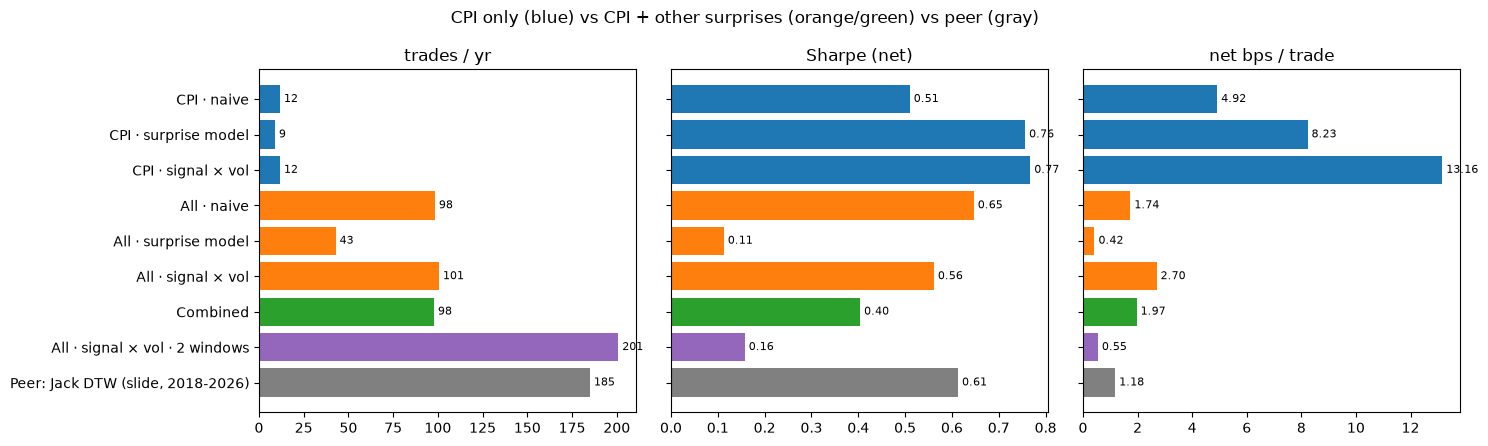

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
lab = [s.replace(" (CPI model + others × vol)", "") for s in final.index]
for ax, col in zip(axes, ["trades / yr", "Sharpe (net)", "net bps / trade"]):
    vals = final[col].values
    ax.barh(lab, vals, color=["C0"] * 3 + ["C1"] * 3 + ["C2", "C4", "gray"])
    ax.axvline(0, c="k", lw=0.5); ax.set_title(col); ax.invert_yaxis()
    for i, v in enumerate(vals):
        if np.isfinite(v):
            ax.text(v, i, f" {v:.2f}" if col != "trades / yr" else f" {v:.0f}", va="center", fontsize=8)
    if ax is not axes[0]:
        ax.set_yticklabels([])
plt.suptitle("CPI only (blue) vs CPI + other surprises (orange/green) vs peer (gray)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "nb05_final_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

### 10.1 Automatic summary

In [18]:
def line(s):
    r = final.loc[s]
    return (f"{s:<40s} {r['trades / yr']:6.0f} trades/yr | Sharpe {r['Sharpe (net)']:5.2f} | "
            f"{r['net bps / trade']:6.2f} bps/trade | total {r['total net P&L %']:6.2f}% | "
            f"maxDD {r['max DD %']:6.2f}% | ex-2022 Sharpe {r['Sharpe ex-2022']:5.2f} | P(random) {r['P(random sign ≥)']:.3f}")
print("=" * 120)
print("NOTEBOOK 05 SUMMARY — ES, 2019-2026, net of costs")
print("=" * 120)
print("CPI only:")
for s in FINAL[:3]: print("  " + line(s))
print("CPI + other surprises:")
for s in FINAL[3:]: print("  " + line(s))
print(f"\nPeer (Jack DTW slide): 185 trades/yr | Sharpe 0.61 | 1.18 bps/trade | total 18.6% | maxDD -4.9%")
best = final.drop(index=final.index[-1])["Sharpe (net)"].idxmax()
print(f"\nHighest net Sharpe: {best}")
print(f"Families admitted at least once: {', '.join(sorted(admitted_any.index))}")

NOTEBOOK 05 SUMMARY — ES, 2019-2026, net of costs
CPI only:
  CPI · naive                                  12 trades/yr | Sharpe  0.51 |   4.92 bps/trade | total   4.33% | maxDD  -2.20% | ex-2022 Sharpe -0.11 | P(random) 0.030
  CPI · surprise model                          9 trades/yr | Sharpe  0.76 |   8.23 bps/trade | total   5.51% | maxDD  -2.04% | ex-2022 Sharpe  0.05 | P(random) 0.006
  CPI · signal × vol                           12 trades/yr | Sharpe  0.77 |  13.16 bps/trade | total  11.58% | maxDD  -2.64% | ex-2022 Sharpe  0.05 | P(random) 0.008
CPI + other surprises:
  All · naive                                  98 trades/yr | Sharpe  0.65 |   1.74 bps/trade | total  12.79% | maxDD  -4.84% | ex-2022 Sharpe  0.28 | P(random) 0.000
  All · surprise model                         43 trades/yr | Sharpe  0.11 |   0.42 bps/trade | total   1.35% | maxDD  -3.24% | ex-2022 Sharpe -0.16 | P(random) 0.095
  All · signal × vol                          101 trades/yr | Sharpe  0.56 |   2.7

## 11. Interpretation and Conclusion

*Fill this in after running, using the summary above. Suggested structure:*

**1. Trade count.** How many trades a year does CPI + other surprises give, compared with CPI only (about 7–11) and the peer strategy (185)?

**2. Edge per trade.** Does net bps per trade stay above the cost when weaker releases are added? Which families earn money (Section 9.2), and which only add costs?

**3. Risk-adjusted return.** Compare the Sharpe of CPI only, All, and Combined. Is the difference robust? Check `P(random sign ≥)`, the Sharpe excluding 2022, and the two sub-periods.

**4. Sizing.** Does Jack's signal × volatility sizing improve the multi-release book, as it did in his split test?

**5. Second window.** Does a second 30-minute trade after each release add profit, or only trades?

**6. Recommendation.** CPI only, CPI + others, or the combined book, and why.

# 12. Purpose, Research Questions, Answers, and Conclusion

## Purpose of Notebook 05

Notebook 04 showed that trading ES in the direction of the **CPI surprise** is profitable after costs, but with only about **7–11 trades a year**. The peer DTW strategy (Jack Duncan) trades about **185 times a year on ES**.

Notebook 05 asks:

> **If we trade the surprises of many US macro releases, not only CPI, how many trades do we get, and do we keep a positive, credible edge after costs?**

**Design:** ES only; entry at the close of the first post-release bar (T+1), exit 30 minutes after the release; walk-forward evaluation over **2019–2026**, with 2016–2018 used only as history. Costs are 2 ticks plus $4.50 per round trip.

**Credits:** the release-family rule, the impact screen and the volatility-proportional sizing come from **Jack Duncan**; the ±5σ winsorisation from **Aaryen Mehta**; the causal surprises, executable entry and walk-forward engine from Notebooks 01–04.

---

## Research Questions and Answers

### Section 2: How many distinct releases are there?
**Question:** How many independent release events does the Bloomberg workbook contain once lines printed at the same instant are grouped?

**Answer:** 27,137 release rows across 179 lines. The 143 lines with enough history collapse into **75 release families**. For example, CPI MoM, Core CPI MoM, CPI YoY and the CPI index lines form **one CPI family**, and payrolls, the unemployment rate and hourly earnings form **one Employment Report family**. Each family release is one trade.

### Section 3: Are the surprises well behaved?
**Question:** Can every line be turned into a causal, comparable surprise?

**Answer:** Yes. 17,328 surprises have a causal z-score (at least 24 prior releases), and only **0.47%** hit the ±5σ cap.

### Section 5: Does Notebook 05 reproduce Notebook 04?
**Question:** Are the trade returns identical to Notebook 04 for the same CPI releases?

**Answer:** **Yes.** On all 86 CPI releases the 30-minute trade return matches Notebook 04 (maximum difference 3.6×10⁻¹⁵ bps).

### Section 6: Which releases does the market react to?
**Question:** Which families move ES more than other releases at the same clock time, using history only?

**Answer:** The screen is stable at the top. **CPI** ranks 1st–5th every year (1st from 2023), the **Employment Report** 1st–4th, and **Retail Sales**, **ISM Services** and **ISM Manufacturing** are regularly admitted. From 2020 the **FOMC decision** also ranks high, but it has almost no surprise to trade (only 1 trade in 7.5 years). This is a limitation of the screen.

### Section 7: Is the direction signal sensible?
**Question:** With each line signed by its historical jump reaction, does the signal relate to the market's reaction out of sample?

**Answer:** Yes, for most families. The correlation between the signal and the instant jump in 2019–2026 is **+0.55 for CPI** and positive for most admitted families (U. of Michigan +0.58, PPI +0.41, ISM Manufacturing +0.37, Retail Sales +0.24). All CPI lines are correctly signed: a hot print pushes ES down.

### Section 9.1: How many trades, and how profitable?

| Strategy | Trades / yr | Days / yr | Net bps / trade | Total net P&L | Net Sharpe | Max DD |
|---|---|---|---|---|---|---|
| CPI · naive | 12 | 12 | 4.9 | 4.3% | 0.51 | −2.2% |
| CPI · surprise model | 9 | 9 | 8.2 | 5.5% | 0.76 | −2.0% |
| **CPI · signal × vol** | 12 | 12 | **13.2** | 11.6% | **0.77** | −2.6% |
| **All · naive** | **98** | **91** | 1.7 | 12.8% | **0.65** | −4.8% |
| All · surprise model | 43 | 42 | 0.4 | 1.4% | 0.11 | −3.2% |
| All · signal × vol | 101 | 92 | 2.7 | **20.3%** | 0.56 | −13.8% |
| Combined (CPI model + others × vol) | 98 | 89 | 2.0 | 14.4% | 0.40 | −14.3% |
| All · signal × vol · 2 windows | 201 | 92 | 0.5 | 8.2% | 0.16 | −23.8% |
| *Peer: Jack DTW (slide)* | *185* | — | *1.2* | *18.6%* | *0.61* | *−4.9%* |

### Section 9.2: Which releases earn money?
**Answer:** Positive total net P&L (naive sizing): **CPI +4.3%**, JOLTS +3.0%, Retail Sales +2.3%, U. of Michigan +1.4%, Advance Goods Trade +1.3%. Negative: Employment Report −1.7%, ISM Services −1.5%, Case-Shiller −1.0%, Pending Home Sales −0.6%. **No family is individually significant.** The only t-stat above 2 is CPI with volatility sizing (2.04). The broad book works through **diversification across many small edges**.

### Section 9.4: Is the edge robust?

| Strategy | Sharpe 2019–21 | Sharpe 2022–26 | Sharpe ex-2022 | Random-sign p |
|---|---|---|---|---|
| CPI · surprise model | 0.63 | 0.83 | 0.05 | 0.006 |
| CPI · signal × vol | 0.53 | 0.91 | 0.05 | 0.008 |
| **All · naive** | 0.32 | 0.83 | **0.28** | **< 0.001** |
| All · signal × vol | −0.06 | 1.42 | 0.12 | 0.014 |
| All · naive · 2nd window only | −1.63 | −0.27 | −1.03 | 0.59 |

- **The direction is real.** No random-direction book out of 1,000 matched the multi-release naive book (p < 0.001), and CPI is also significant (p < 0.01).
- **The multi-release book depends less on 2022** than CPI alone (Sharpe excluding 2022: 0.28 vs about 0.05).
- **The second window loses money** (Sharpe −0.79, hit rate 45%). The surprise's effect is gone within 30 minutes.

### Section 9.5: How sensitive is it to costs?

| Round-trip slippage | 0 ticks | 1 | 2 (base) | 4 |
|---|---|---|---|---|
| All · naive | 1.09 | 0.87 | 0.65 | **0.20** |
| CPI · surprise model | 0.66 | 0.60 | 0.76 | **0.61** |

With only 1.7 bps per trade, the multi-release book depends heavily on **execution quality**. CPI's larger edge per trade barely notices costs.

### Section 9.6: Is it market-neutral?
**Answer:** Yes. Beta to buy-and-hold ES is between −0.003 and +0.002 for every strategy, and time in market is below 1% (1.8% for the two-window book).

---

## An Important Finding: The CPI Surprise Definition

Notebook 05's **CPI naive** book (Sharpe 0.51) is weaker than Notebook 04's (Sharpe 1.03), **even though the trade returns are identical**. The only difference is the signal:

- **Notebook 04:** headline CPI MoM surprise only.
- **Notebook 05:** the average of all 8 CPI lines (headline, core, YoY, index levels, real earnings).

The two signals disagree in direction on **20 of 86 releases (23%)**. These are mostly months where the headline surprise was **almost exactly zero** (|z| < 0.2), so the "direction" is essentially a coin flip. Those 20 trades alone swing P&L by about **4.3 percentage points**, including a single release (January 2023) worth +115 bps under one definition and −118 bps under the other.

**Lesson:** part of the Notebook 04 CPI result comes from near-zero surprises, where the sign depends on the definition. The **surprise-model** and **signal × volatility** versions reduce this problem by trading little or nothing on small surprises, which is why they are more stable (Sharpe 0.76–0.77) and significant against the random-sign test.

---

## Final Comparison: CPI Only vs CPI + Other Surprises

| | **CPI only** (best: signal × vol) | **CPI + other surprises** (All · naive) | Peer: Jack DTW |
|---|---|---|---|
| Trades per year | 12 | **98** | 185 |
| Trading days per year | 12 | **91** | — |
| Net bps per trade | **13.2** | 1.7 | 1.2 |
| Total net P&L (2019–26) | 11.6% | 12.8% | 18.6% (2018–26) |
| Net Sharpe | **0.77** | 0.65 | 0.61 |
| Max drawdown | −2.6% | −4.8% | −4.9% |
| Sharpe ex-2022 | 0.05 | **0.28** | — |
| Robust to 4-tick costs | **Yes (0.61)** | No (0.20) | — |

---

## Conclusion

**1. We can trade much more often.** Trading the surprises of about 10 screened releases gives **~98 trades a year on ~91 days**, against 7–12 for CPI only.

**2. The edge survives, at a level comparable to the peer strategy.** The multi-release book earns a **net Sharpe of 0.65** with a −4.8% drawdown, essentially matching the peer DTW strategy (0.61, −4.9%). It does so with an **economically explained signal** and a larger edge per trade (1.7 vs 1.2 bps).

**3. More trades bring less dependence on 2022, but more dependence on execution.** The multi-release book is more stable across years than CPI alone (Sharpe ex-2022 0.28 vs 0.05), but its Sharpe falls from 0.65 to 0.20 if slippage doubles to 4 ticks.

**4. CPI remains the strongest single release.** With surprise-model or volatility sizing, CPI reaches **Sharpe ~0.77** at **8–13 bps per trade** and is robust to costs.

**5. The effect lasts about 30 minutes.** A second trade after each release loses money (Sharpe −0.79). Reaching ~200 trades a year this way would **lower** the Sharpe to 0.16, so the honest ceiling is about **100 trades a year**.

**6. Sizing matters, but not the way we expected.** Jack's volatility sizing increases P&L but raises the drawdown to about −14% and lost money in 2019–21. Fitting a separate model per release (the surprise model) **hurts** the multi-release book (Sharpe 0.11), because about 24 past releases per family are too few.

**Recommendation:** use a **two-part book**:
- a **CPI leg** (surprise model or signal × volatility) as the core, robust signal;
- a **multi-release leg** (naive sign) to add trades and diversification, on the condition that execution costs stay near 2 ticks.

**Caveats and next steps:**
- the CPI result depends on the surprise definition for near-zero surprises; a fixed definition (for example core CPI MoM, or skipping |z| < 0.5) should be tested and **labelled as a post-hoc refinement**;
- the impact screen should exclude families with no real surprise (FOMC, interest on reserves);
- performance is concentrated in the 2022 inflation regime;
- execution in the first minute after a release may cost more than 2 ticks, so a paper-trading test with real fills is the natural next step.

> **Overall:** trading the macro surprise across about 10 major US releases turns a 7–11 trade-a-year CPI strategy into a ~100 trade-a-year book with a net Sharpe of about 0.65, matching the peer DTW strategy's risk-adjusted return with an economically grounded signal. The surprise's effect lasts about 30 minutes, and CPI remains its strongest and most cost-robust source.

# 12. Purpose, Research Questions, Answers, and Conclusion (ES)

## Purpose of Notebook 05

Notebook 04 showed that trading ES in the direction of the **CPI surprise** is profitable after costs, but with only about **7–11 trades a year**. The peer DTW strategy (Jack Duncan) trades about **185 times a year on ES**.

Notebook 05 asks:

> **If we trade the surprises of many US macro releases, not only CPI, how many trades do we get, and do we keep a positive, credible edge after costs?**

**Design:** ES only; entry at the close of the first post-release bar (T+1), exit 30 minutes after the release; walk-forward evaluation over **2019–2026**, with 2016–2018 used only as history. Costs are 2 ticks plus $4.50 per round trip on the ES contract, about **1.7 bps** on average.

The same notebook was repeated for NQ and ZN (Notebooks 05b); their results are shown for reference at the end.

**Credits:** the release-family rule, the impact screen and the volatility-proportional sizing come from **Jack Duncan**; the ±5σ winsorisation from **Aaryen Mehta**; the causal surprises, executable entry and walk-forward engine from Notebooks 01–04.

---

## Research Questions and Answers

### Section 2: How many distinct releases are there?
**Question:** How many independent release events does the Bloomberg workbook contain once lines printed at the same instant are grouped?

**Answer:** 27,137 release rows across 179 lines. The 143 lines with enough history collapse into **75 release families**. For example, CPI MoM, Core CPI MoM, CPI YoY and the CPI index lines form **one CPI family**, and payrolls, the unemployment rate and hourly earnings form **one Employment Report family**. Each family release is one trade.

### Section 3: Are the surprises well behaved?
**Question:** Can every line be turned into a causal, comparable surprise?

**Answer:** Yes. 17,328 surprises have a causal z-score (at least 24 prior releases), and only **0.47%** hit the ±5σ cap.

### Section 5: Does Notebook 05 reproduce Notebook 04?
**Question:** Are the trade returns identical to Notebook 04 for the same CPI releases?

**Answer:** **Yes.** On all 86 CPI releases the 30-minute trade return matches Notebook 04 (maximum difference 3.6×10⁻¹⁵ bps).

### Section 6: Which releases does the market react to?
**Question:** Which families move ES more than other releases at the same clock time, using history only?

**Answer:** The screen is stable at the top. **CPI** ranks 1st–5th every year (1st from 2023), the **Employment Report** 1st–4th, and **Retail Sales**, **ISM Services** and **ISM Manufacturing** are regularly admitted. From 2020 the **FOMC decision** also ranks high, but it has almost no surprise to trade (only 1 trade in 7.5 years). This is a limitation of the screen.

### Section 7: Is the direction signal sensible?
**Question:** With each line signed by its historical jump reaction, does the signal relate to the market's reaction out of sample?

**Answer:** Yes, for most families. The correlation between the signal and the instant jump in 2019–2026 is **+0.55 for CPI** and positive for most admitted families (U. of Michigan +0.58, PPI +0.41, ISM Manufacturing +0.37, Retail Sales +0.24). All CPI lines are correctly signed: a hot print pushes ES down.

### Section 9.1: How many trades, and how profitable?

| Strategy | Trades / yr | Days / yr | Net bps / trade | Total net P&L | Net Sharpe | Max DD |
|---|---|---|---|---|---|---|
| CPI · naive | 12 | 12 | 4.9 | 4.3% | 0.51 | −2.2% |
| CPI · surprise model | 9 | 9 | 8.2 | 5.5% | 0.76 | −2.0% |
| **CPI · signal × vol** | 12 | 12 | **13.2** | 11.6% | **0.77** | −2.6% |
| **All · naive** | **98** | **91** | 1.7 | 12.8% | **0.65** | −4.8% |
| All · surprise model | 43 | 42 | 0.4 | 1.4% | 0.11 | −3.2% |
| All · signal × vol | 101 | 92 | 2.7 | **20.3%** | 0.56 | −13.8% |
| Combined (CPI model + others × vol) | 98 | 89 | 2.0 | 14.4% | 0.40 | −14.3% |
| All · signal × vol · 2 windows | 201 | 92 | 0.5 | 8.2% | 0.16 | −23.8% |
| *Peer: Jack DTW (slide)* | *185* | — | *1.2* | *18.6%* | *0.61* | *−4.9%* |

### Section 9.2: Which releases earn money?
**Answer:** Positive total net P&L (naive sizing): **CPI +4.3%**, JOLTS +3.0%, Retail Sales +2.3%, U. of Michigan +1.4%, Advance Goods Trade +1.3%. Negative: Employment Report −1.7%, ISM Services −1.5%, Case-Shiller −1.0%, Pending Home Sales −0.6%. **No family is individually significant.** The only t-stat above 2 is CPI with volatility sizing (2.04). The broad book works through **diversification across many small edges**.

### Section 9.4: Is the edge robust?

| Strategy | Sharpe 2019–21 | Sharpe 2022–26 | Sharpe ex-2022 | Random-sign p |
|---|---|---|---|---|
| CPI · surprise model | 0.63 | 0.83 | 0.05 | 0.006 |
| CPI · signal × vol | 0.53 | 0.91 | 0.05 | 0.008 |
| **All · naive** | 0.32 | 0.83 | **0.28** | **< 0.001** |
| All · signal × vol | −0.06 | 1.42 | 0.12 | 0.014 |
| All · naive · 2nd window only | −1.63 | −0.27 | −1.03 | 0.59 |

- **The direction is real.** No random-direction book out of 1,000 matched the multi-release naive book (p < 0.001), and CPI is also significant (p < 0.01).
- **The multi-release book depends less on 2022** than CPI alone (Sharpe excluding 2022: 0.28 vs about 0.05).
- **The second window loses money** (Sharpe −0.79, hit rate 45%). The surprise's effect is gone within 30 minutes.

### Section 9.5: How sensitive is it to costs?

| Round-trip slippage | 0 ticks | 1 | 2 (base) | 4 |
|---|---|---|---|---|
| All · naive | 1.09 | 0.87 | 0.65 | **0.20** |
| CPI · surprise model | 0.66 | 0.60 | 0.76 | **0.61** |

With only 1.7 bps per trade, the multi-release book depends heavily on **execution quality**. CPI's larger edge per trade barely notices costs.

### Section 9.6: Is it market-neutral?
**Answer:** Yes. Beta to buy-and-hold ES is between −0.003 and +0.002 for every strategy, and time in market is below 1% (1.8% for the two-window book).

---

## An Important Finding: The CPI Surprise Definition

Notebook 05's **CPI naive** book (Sharpe 0.51) is weaker than Notebook 04's (Sharpe 1.03), **even though the trade returns are identical**. The only difference is the signal:

- **Notebook 04:** headline CPI MoM surprise only.
- **Notebook 05:** the average of all 8 CPI lines (headline, core, YoY, index levels, real earnings).

The two signals disagree in direction on **20 of 86 releases (23%)**. These are mostly months where the headline surprise was **almost exactly zero** (|z| < 0.2), so the "direction" is essentially a coin flip. Those 20 trades alone swing P&L by about **4.3 percentage points**, including a single release (January 2023) worth +115 bps under one definition and −118 bps under the other.

The same gap appears in NQ (Notebook 04b naive 1.00 vs Notebook 05b 0.54), so it is a property of the signal definition, not of the market.

**Lesson:** part of the Notebook 04 CPI result comes from near-zero surprises, where the sign depends on the definition. The **surprise-model** and **signal × volatility** versions reduce this problem by trading little or nothing on small surprises, which is why they are more stable (Sharpe 0.76–0.77) and significant against the random-sign test.

---

## Final Comparison: CPI Only vs CPI + Other Surprises

| | **CPI only** (best: signal × vol) | **CPI + other surprises** (All · naive) | Peer: Jack DTW |
|---|---|---|---|
| Trades per year | 12 | **98** | 185 |
| Trading days per year | 12 | **91** | — |
| Net bps per trade | **13.2** | 1.7 | 1.2 |
| Total net P&L (2019–26) | 11.6% | 12.8% | 18.6% (2018–26) |
| Net Sharpe | **0.77** | 0.65 | 0.61 |
| Max drawdown | −2.6% | −4.8% | −4.9% |
| Sharpe ex-2022 | 0.05 | **0.28** | — |
| Robust to 4-tick costs | **Yes (0.61)** | No (0.20) | — |

### The same test in NQ and ZN (Notebooks 05b)

| Net Sharpe, 2019–2026 | ES | NQ | ZN |
|---|---|---|---|
| Average cost (bps) | 1.7 | 0.8 | 3.0 |
| CPI · surprise model | 0.76 | 0.55 | −0.37 (1 trade) |
| CPI · signal × vol | **0.77** | **0.74** | −0.29 |
| **All · naive** (trades / yr) | **0.65** (98) | **0.71** (97) | −2.42 (82) |
| All · naive, Sharpe ex-2022 | 0.28 | **0.44** | −2.53 |
| All · naive, random-sign p | < 0.001 | 0.005 | 0.81 |
| All · naive at 4-tick costs | 0.20 | **0.60** | −4.24 |
| 2-window book | 0.16 | 0.00 | −2.02 |

---

## Conclusion

**1. We can trade much more often.** Trading the surprises of about 10 screened releases gives **~98 trades a year on ~91 days**, against 7–12 for CPI only.

**2. The edge survives, at a level comparable to the peer strategy.** The multi-release book earns a **net Sharpe of 0.65** with a −4.8% drawdown, essentially matching the peer DTW strategy (0.61, −4.9%). It does so with an **economically explained signal** and a larger edge per trade (1.7 vs 1.2 bps).

**3. More trades bring less dependence on 2022, but more dependence on execution.** The multi-release book is more stable across years than CPI alone (Sharpe ex-2022 0.28 vs 0.05), but its Sharpe falls from 0.65 to 0.20 if slippage doubles to 4 ticks.

**4. CPI remains the strongest single release.** With surprise-model or volatility sizing, CPI reaches **Sharpe ~0.77** at **8–13 bps per trade** and is robust to costs.

**5. The effect lasts about 30 minutes.** A second trade after each release loses money (Sharpe −0.79). Reaching ~200 trades a year this way would **lower** the Sharpe to 0.16, so the honest ceiling is about **100 trades a year per market**.

**6. Sizing matters, but not the way we expected.** Jack's volatility sizing increases P&L but raises the drawdown to about −14% and lost money in 2019–21. Fitting a separate model per release (the surprise model) **hurts** the multi-release book (Sharpe 0.11), because about 24 past releases per family are too few.

**7. The result holds in NQ, not in ZN.** The same book on NQ earns a Sharpe of **0.71**, depends less on 2022 (0.44 ex-2022) and is much more cost-robust (0.60 at 4 ticks). On ZN every book loses money, even without slippage, because the bond market prices the surprise in the first minute. The multi-release surprise book is an **equity-index strategy**: ES and NQ together give about **200 trades a year** (Notebook 07: Sharpe 0.72).

**Recommendation:** use a **two-part book**:
- a **CPI leg** (surprise model or signal × volatility) as the core, robust signal;
- a **multi-release leg** (naive sign) to add trades and diversification, run on **both ES and NQ**, on the condition that execution costs stay near 2 ticks.

**Caveats and next steps:**
- the CPI result depends on the surprise definition for near-zero surprises; a fixed definition (for example core CPI MoM, or skipping |z| < 0.5) should be tested and **labelled as a post-hoc refinement**;
- the impact screen should exclude families with no real surprise (FOMC, interest on reserves);
- performance is concentrated in the 2022 inflation regime;
- execution in the first minute after a release may cost more than 2 ticks, so a paper-trading test with real fills is the natural next step.

> **Overall:** trading the macro surprise across about 10 major US releases turns a 7–11 trade-a-year CPI strategy into a ~100 trade-a-year book with a net Sharpe of about 0.65 on ES and 0.71 on NQ. That matches or beats the peer DTW strategy's risk-adjusted return with an economically grounded signal. The surprise's effect lasts about 30 minutes, CPI remains its strongest and most cost-robust source, and the strategy does not work on ZN.

---

## The Same Test in NQ and ZN (Notebooks 05b)

| Net Sharpe, 2019–2026 | ES | NQ | ZN |
|---|---|---|---|
| Average cost (bps) | 1.7 | 0.8 | 3.0 |
| CPI · surprise model | 0.76 | 0.55 | −0.37 (1 trade) |
| CPI · signal × vol | **0.77** | **0.74** | −0.29 |
| **All · naive** (trades / yr) | **0.65** (98) | **0.71** (97) | −2.42 (82) |
| All · naive, Sharpe ex-2022 | 0.28 | **0.44** | −2.53 |
| All · naive, random-sign p | < 0.001 | 0.005 | 0.81 |
| All · naive at 4-tick costs | 0.20 | **0.60** | −4.24 |
| 2-window book | 0.16 | 0.00 | −2.02 |

**Reading:**
- The multi-release book works in **both equity index markets**. NQ is even slightly stronger and much more cost-robust than ES, because a tick is a smaller share of the NQ price.
- In both equity markets the effect lasts about 30 minutes: second windows lose money, so the ceiling is about **100 trades a year per market**. Two equity markets together give about **200 trades a year** (Notebook 07: ES+NQ, Sharpe 0.72).
- **ZN is not tradeable:** the bond market prices the surprise in the first minute, and every ZN book loses money, even without slippage.